# Products EDA

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")
pd.set_option("display.max_columns", None)

In [3]:
products = pd.read_csv("../04_Feature_Engineering/Output/products_features.csv")

In [4]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_volume_cm3
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,2240.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,10800.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,2430.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0,2704.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0,4420.0


In [5]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
 9   product_volume_cm3          32949 non-null  float64
dtypes: float64(8), object(2)
memory usage: 2.5+ MB


In [6]:
products.describe(include="all")

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_volume_cm3
count,32951,32341,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000,32949.000000
unique,32951,73,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,1e9e8ef04dbcff4541ed26657ea517e5,cama_mesa_banho,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,3029,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728,16564.096695
std,NaN,NaN,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047,27057.041650
min,NaN,NaN,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000,168.000000
25%,NaN,NaN,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000,2880.000000
50%,NaN,NaN,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000,6840.000000
75%,NaN,NaN,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000,18480.000000


In [7]:
products.isnull().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
product_volume_cm3              2
dtype: int64

In [8]:
products.duplicated().sum()

0

## 1. Product Category Analysis

In [9]:
products["product_category_name"].value_counts()

product_category_name
cama_mesa_banho                  3029
esporte_lazer                    2867
moveis_decoracao                 2657
beleza_saude                     2444
utilidades_domesticas            2335
                                 ... 
fashion_roupa_infanto_juvenil       5
casa_conforto_2                     5
pc_gamer                            3
seguros_e_servicos                  2
cds_dvds_musicais                   1
Name: count, Length: 73, dtype: int64

In [10]:
category_pct = (
    products["product_category_name"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index()
)

category_pct.columns = ["product_category_name", "percentage"]

category_pct

,product_category_name,percentage
0,cama_mesa_banho,9.37
1,esporte_lazer,8.86
2,moveis_decoracao,8.22
3,beleza_saude,7.56
4,utilidades_domesticas,7.22
...,...,...
68,fashion_roupa_infanto_juvenil,0.02
69,casa_conforto_2,0.02
70,pc_gamer,0.01
71,seguros_e_servicos,0.01


In [11]:
top_categories = (
    products["product_category_name"]
    .value_counts()
    .head(20)
    .reset_index()
)

top_categories.columns = ["product_category_name", "count"]

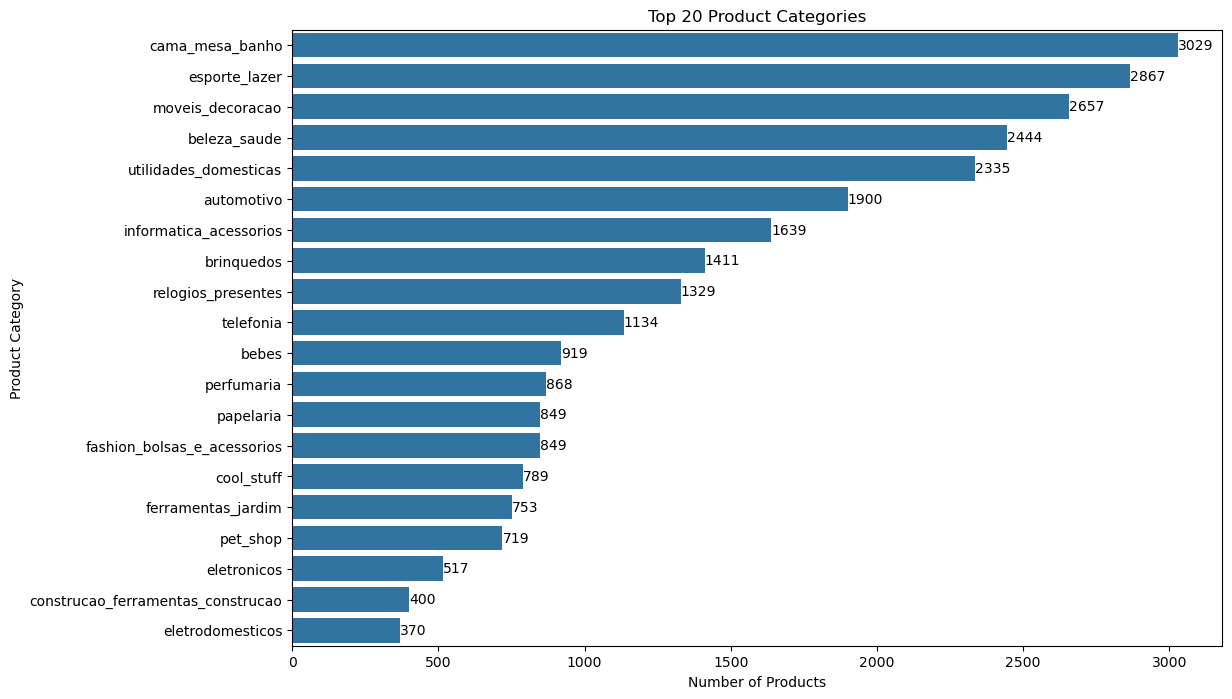

In [12]:
plt.figure(figsize=(12,8))

ax = sns.barplot(
    data=top_categories,
    x="count",
    y="product_category_name"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Top 20 Product Categories")
plt.xlabel("Number of Products")
plt.ylabel("Product Category")

plt.show()

## 2. Product Content Analysis

In [14]:
# HElper Function ( Same as created previously)
def analyze_numeric_feature(df, column, bins=50):
    """
    Performs basic EDA for a numeric feature.
    """

    print("=" * 60)
    print(f"EDA for: {column}")
    print("=" * 60)

    # Summary Statistics
    print("\nSummary Statistics\n")
    print(df[column].describe())

    # Missing Values
    print("\nMissing Values\n")
    print(df[column].isnull().sum())

    # Histogram
    plt.figure(figsize=(8, 5))

    sns.histplot(
        data=df,
        x=column,
        bins=bins,
        kde=True
    )

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")

    plt.show()

    # Boxplot
    plt.figure(figsize=(8, 2))

    sns.boxplot(
        data=df,
        x=column
    )

    plt.title(f"Boxplot of {column}")

    plt.show()

    # Largest Values
    print("\nTop 10 Largest Values\n")
    print(df[column].nlargest(10))

    # Smallest Values
    print("\nTop 10 Smallest Values\n")
    print(df[column].nsmallest(10))

EDA for: product_volume_cm3

Summary Statistics

count     32949.000000
mean      16564.096695
std       27057.041650
min         168.000000
25%        2880.000000
50%        6840.000000
75%       18480.000000
max      296208.000000
Name: product_volume_cm3, dtype: float64

Missing Values

2


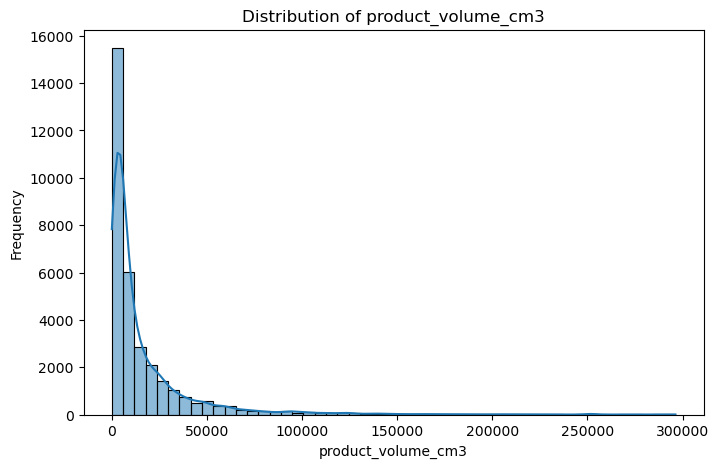

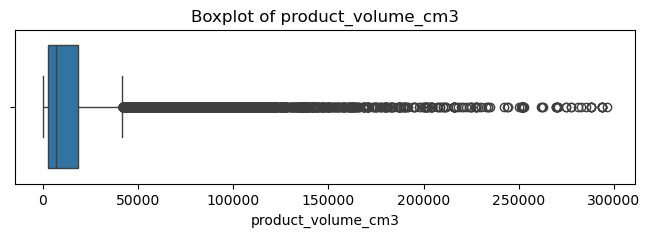


Top 10 Largest Values

12802    296208.0
10697    294000.0
12146    294000.0
17303    294000.0
25524    294000.0
32532    293706.0
3770     288000.0
7234     288000.0
16728    288000.0
28145    287980.0
Name: product_volume_cm3, dtype: float64

Top 10 Smallest Values

32950    168.0
961      288.0
15       352.0
102      352.0
124      352.0
132      352.0
180      352.0
192      352.0
194      352.0
201      352.0
Name: product_volume_cm3, dtype: float64


In [16]:
analyze_numeric_feature(products, "product_volume_cm3")

## Overall Observations

* Olist offers products across a wide range of categories, indicating a diverse product catalog.
* Product availability is concentrated in a subset of categories, while many categories contain relatively fewer products.
* Product volume varies considerably, suggesting substantial differences in package size and storage requirements.
* A small number of products occupy exceptionally large volumes compared with the majority of the catalog.

## Business Insights

* Product category distribution can support inventory planning and category-level sales analysis.
* Product volume is an important logistics metric that can influence warehouse utilization, packaging strategies, and transportation efficiency.
* Large-volume products may require specialized storage and handling, increasing fulfillment costs.
* Combining product volume with order and seller data in later phases can help identify categories that are more expensive to store and ship.